# DMPC + Flow Matching + CBF Demo

This notebook demonstrates the complete pipeline:
1. Dataset generation
2. Flow Matching model training
3. Two-car DMPC simulation with CBF safety
4. Ablation experiments

Device: cuda


## 1. Dataset Generation

In [ ]:
# Load if exists; otherwise generate and save (match 3car pipeline)
from pathlib import Path
import importlib
import numpy as np
import dmpc_fm_cbf.dataset as dataset

dataset = importlib.reload(dataset)
make_center_to_ring_dataset_tracking_oc = dataset.make_center_to_ring_dataset_tracking_oc
add_velocity_fields = dataset.add_velocity_fields

cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

RAW_NPY = cache_dir / "car_ring_track_oc_dataset_v1_v0rand.npy"
IN_NPY  = cache_dir / "car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"

print("Generating dataset...")
data = make_center_to_ring_dataset_tracking_oc(
    N=100,
    T=60,
    radius=3.0,
    save_filename=str(RAW_NPY),
    LOAD_SAVED_DATA=False,
    v0_min=0.15,
    v0_max=0.6,
)

# 濡傛灉浣犲悗缁繕闇€瑕?vel_xy 绛夊瓧娈碉紝鍙互缁х画鍔狅紱鍚﹀垯鍙互鍏堟敞閲婃帀
data = add_velocity_fields(str(RAW_NPY), str(IN_NPY))

assert "states" in data and "goals" in data and "params" in data, \
    "File missing required keys: states/goals/params"

# ----------------------------
# Build 5-channel training tensor
# ----------------------------
states = np.asarray(data["states"], dtype=np.float32)  # (N,T,5) expected

if states.ndim != 3:
    raise ValueError(f"data['states'] should be (N,T,D). Got {states.shape}")

N, T, D = states.shape
if D < 5:
    raise ValueError(f"Need at least 5 state dims to build 5ch. Got D={D}")

# Mentor-style: first 5 dims are [x, y, theta, v, r]
traj_5ch = states[:, :, :5]                 # (N, T, 5)
traj_5ch = np.transpose(traj_5ch, (0, 2, 1))  # (N, 5, T) for Conv1d

print("traj_5ch shape (N,5,T):", traj_5ch.shape)

print("Example channel mins/maxs:")
for c, name in enumerate(["x","y","theta","v","r"]):
    print(f"  {name:>6s}: [{traj_5ch[:,c,:].min(): .3f}, {traj_5ch[:,c,:].max(): .3f}]")

# -------- sanity check: r 鈮?dtheta/dt ? --------
dt = float(data["params"].get("dt", 0.1))
theta = traj_5ch[:, 2, :]   # (N,T)
r     = traj_5ch[:, 4, :]   # (N,T)

dtheta_dt = (theta[:, 1:] - theta[:, :-1]) / dt
# wrap 瑙掑害宸紙閬垮厤 +-pi 璺冲彉鎶婂鏁板紕鐖嗭級
dtheta_dt = (dtheta_dt + np.pi) % (2*np.pi) - np.pi
err = np.abs(r[:, :-1] - dtheta_dt)

print(f"Sanity: mean|r - dtheta/dt| = {err.mean():.4f}, max = {err.max():.4f}")

# (Optional) keep velocity fields if you still need them elsewhere
if "vel_xy_Tm1" in data:
    vel_xy = np.asarray(data["vel_xy_Tm1"])
    print("vel_xy_Tm1 shape:", vel_xy.shape)


Generating dataset...
Generating tracking optimal-control ring dataset ...
10% (10/100) done. last success=True
20% (20/100) done. last success=True
30% (30/100) done. last success=True
40% (40/100) done. last success=True
50% (50/100) done. last success=True
60% (60/100) done. last success=True
70% (70/100) done. last success=True
80% (80/100) done. last success=True
90% (90/100) done. last success=True
100% (100/100) done. last success=True
Saved: cache\car_ring_track_oc_dataset_v1_v0rand.npy
Saved: cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy
keys: ['traj_xy', 'states', 'controls', 'goals', 'params', 'vel_xy', 'vel_xy_N2T', 'vel_xy_Tm1', 'vel_xy_Tm1_N2T', 'omega']
states: (100, 60, 5)
vel_xy (N,T,2): (100, 60, 2)
vel_xy_N2T (N,2,T): (100, 2, 60)
vel_xy_Tm1_N2T (N,2,T-1): (100, 2, 59)
omega: (100, 60)
dt: 0.1 T: 60
traj_5ch shape (N,5,T): (100, 5, 60)
Example channel mins/maxs:
       x: [-2.953,  2.956]
       y: [-2.928,  2.985]
   theta: [-3.142,  3.139]
       v: [ 0.00

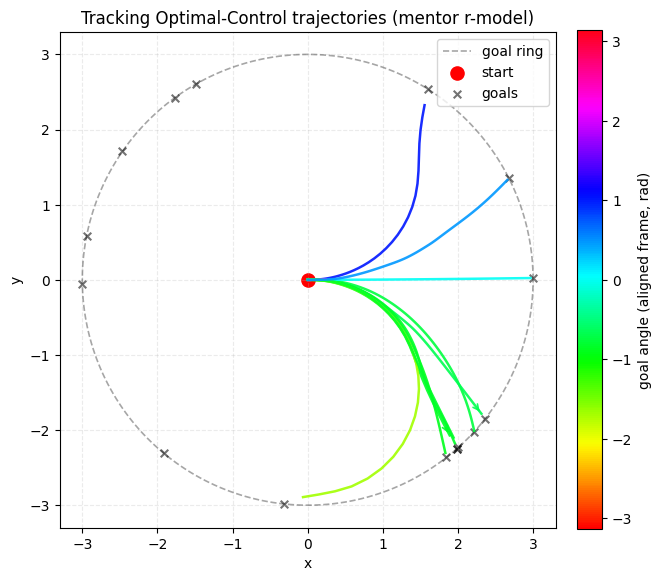

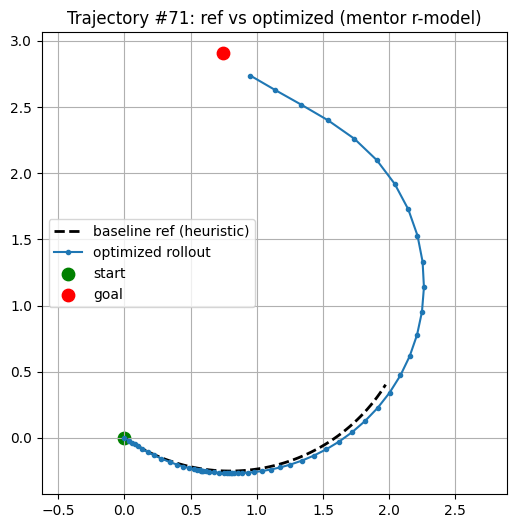

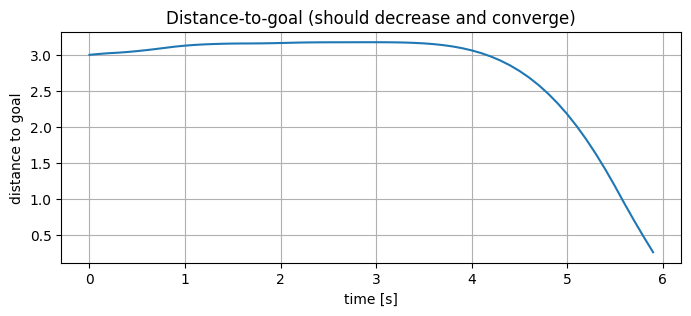

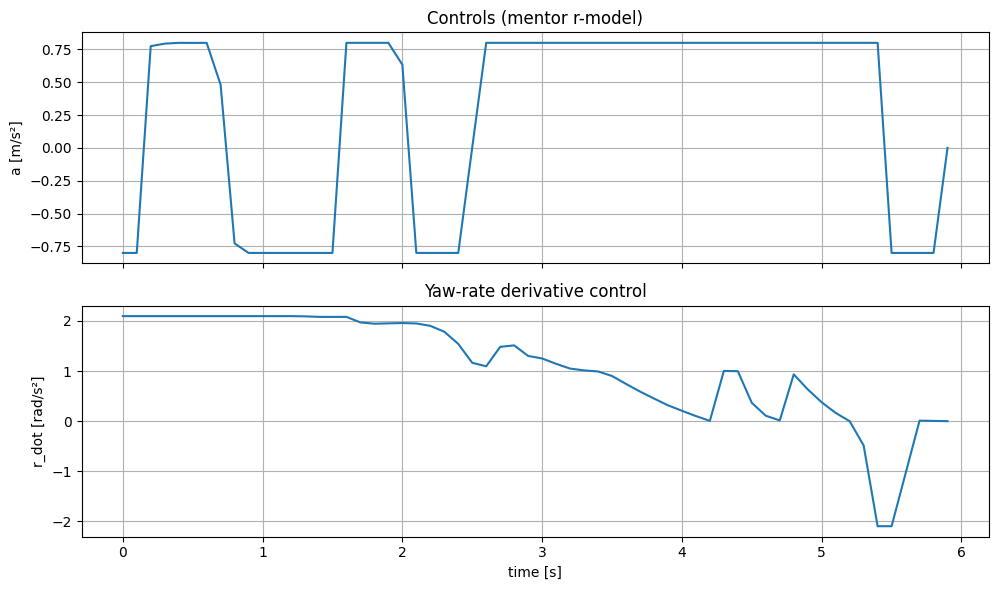

In [ ]:
# Visualize trajectories (same style as original notebook) 鈥?UPDATED for mentor r-model
# State: [x,y,theta,v,r], Control: [a, r_dot]

from dmpc_fm_cbf import dataset as ds
import numpy as np
import matplotlib.pyplot as plt

# ---------- keep the same overview plot ----------
plot_all_trajs_timecolor = ds.plot_all_trajs_timecolor
plot_all_trajs_timecolor(
    data["traj_xy"],
    data["goals"],
    theta0=data.get("theta0"),
    align_start_to_right=True,
    title="Tracking Optimal-Control trajectories (mentor r-model)",
)

# ---------- updated single-trajectory plot (ref vs optimized + distance + controls) ----------
def plot_one_compare_rmodel(data, idx=None):
    traj_xy = data["traj_xy"]
    refs_xy = data["refs_xy"]
    goals = data["goals"]
    controls = data["controls"]
    dt = float(data["params"].get("dt", 0.1))

    N, _, T = traj_xy.shape
    if idx is None:
        idx = np.random.randint(N)

    xy = traj_xy[idx].T    # (T,2)
    ref = refs_xy[idx]     # (T,2)
    goal = goals[idx]
    u = controls[idx]      # (T,2) padded; u[:-1] is valid

    # 1) XY compare
    plt.figure(figsize=(6,6))
    plt.plot(ref[:,0], ref[:,1], "k--", linewidth=2, label="baseline ref (heuristic)")
    plt.plot(xy[:,0],  xy[:,1],  "-o", markersize=3, label="optimized rollout")
    plt.scatter(xy[0,0], xy[0,1], c="green", s=80, label="start")
    plt.scatter(goal[0], goal[1], c="red",   s=80, label="goal")
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"Trajectory #{idx}: ref vs optimized (mentor r-model)")
    plt.legend()
    plt.show()

    # 2) distance to goal over time
    dist = np.linalg.norm(xy - goal[None,:], axis=1)
    plt.figure(figsize=(8,3))
    plt.plot(np.arange(T)*dt, dist)
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel("distance to goal")
    plt.title("Distance-to-goal (should decrease and converge)")
    plt.show()

    # 3) controls (mentor model: [a, r_dot])
    t = np.arange(T)*dt
    fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    axs[0].plot(t, u[:,0])
    axs[0].set_ylabel("a [m/s虏]")
    axs[0].grid(True)
    axs[0].set_title("Controls (mentor r-model)")

    axs[1].plot(t, u[:,1])
    axs[1].set_ylabel("r_dot [rad/s虏]")
    axs[1].set_xlabel("time [s]")
    axs[1].grid(True)
    axs[1].set_title("Yaw-rate derivative control")

    plt.tight_layout()
    plt.show()

# Run updated single-trajectory comparison
plot_one_compare_rmodel(data, idx=None)


## 2. Model Training

In [ ]:
# ===============================================================
# CANONICALIZED 5-CHANNEL FM TRAINING (mentor-aligned, no obstacle)
# - state = [x, y, theta, v, r]
# - control = [a, r_dot]  (stored in data["controls"] as (N,T,2) padded)
# - train X1 (5ch) in canonical frame:
#     X1 = [x_can, y_can, theta_can, a, r_dot]   shape (N,5,T)
# - cond (5,) = [goal_dist, v0, cos(theta0_can), sin(theta0_can), r0]
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# -------------------------
# 0) Grab raw arrays
# -------------------------
states_np   = np.asarray(data["states"],   dtype=np.float32)   # (N,T,5) = [x,y,theta,v,r]
controls_np = np.asarray(data["controls"], dtype=np.float32)   # (N,T,2) padded = [a, r_dot]
goals_np    = np.asarray(data["goals"],    dtype=np.float32)   # (N,2)

N, T, D = states_np.shape
assert D == 5, f"states must be (N,T,5) [x,y,theta,v,r]. Got {states_np.shape}"
assert controls_np.shape == (N, T, 2), f"controls must be (N,T,2) [a,r_dot]. Got {controls_np.shape}"
assert goals_np.shape == (N, 2), f"goals must be (N,2). Got {goals_np.shape}"

print("raw states:", states_np.shape, "controls:", controls_np.shape, "goals:", goals_np.shape)

# -------------------------
# 1) Canonicalize utilities
# -------------------------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2*np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa],
                     [sa,  ca]], dtype=np.float64)

def canonicalize_episode_5ch_noobs(states_T5, controls_T2, goal_xy):
    """
    states_T5 : (T,5) [x,y,theta,v,r] in world
    controls_T2: (T,2) [a, r_dot] padded
    goal_xy   : (2,)
    Returns:
      x1_5ch : (5,T) = [x_can, y_can, theta_can, a, r_dot]
      cond   : (5,)  = [goal_dist, v0, cos(theta0_can), sin(theta0_can), r0]
    """
    st = np.asarray(states_T5, dtype=np.float64)
    u  = np.asarray(controls_T2, dtype=np.float64)
    g  = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    # start and goal vector
    start_xy = st[0, 0:2].copy()
    g0 = g - start_xy
    goal_dist = float(np.linalg.norm(g0) + 1e-9)

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)  # world -> canonical

    # canonical xy
    xy = st[:, 0:2] - start_xy[None, :]
    xy_can = (R @ xy.T).T  # (T,2)

    # canonical theta
    theta = st[:, 2]
    theta_can = np.array([_wrap_pi(float(th) - phi) for th in theta], dtype=np.float64)

    # build training sequence X1 = [x_can, y_can, theta_can, a, r_dot]
    x1 = np.zeros((5, T), dtype=np.float64)
    x1[0, :] = xy_can[:, 0]
    x1[1, :] = xy_can[:, 1]
    x1[2, :] = theta_can
    x1[3, :] = u[:, 0]  # a
    x1[4, :] = u[:, 1]  # r_dot

    # conditioning
    v0 = float(st[0, 3])
    r0 = float(st[0, 4])
    theta0_can = float(theta_can[0])

    cond = np.array(
        [goal_dist, v0, float(np.cos(theta0_can)), float(np.sin(theta0_can)), r0],
        dtype=np.float64
    )
    return x1.astype(np.float32), cond.astype(np.float32)

# -------------------------
# 2) Build canonical dataset tensors
#    cond5 fixed layout: [goal_dist, v0, cos(theta0_can), sin(theta0_can), r0]
#    (no obstacle in condition)
# -------------------------
from dmpc_fm_cbf.canonical import canonicalize_episode_5d_noobs

X1_list, cond_list = [], []
for i in range(N):
    x1_5ch, c, _ = canonicalize_episode_5d_noobs(states_np[i], controls_np[i], goals_np[i])
    X1_list.append(x1_5ch)   # (5,T)
    cond_list.append(c)      # (5,)

X1   = np.stack(X1_list, axis=0)     # (N,5,T)
cond = np.stack(cond_list, axis=0)   # (N,5)

print("canonical X1:", X1.shape, "cond:", cond.shape)

# -------------------------
# 3) DataLoader (returns (x1, cond))
# -------------------------
class Canonical5chDataset(Dataset):
    def __init__(self, X1, cond):
        self.X1 = torch.from_numpy(np.asarray(X1, dtype=np.float32))      # (N,5,T)
        self.cond = torch.from_numpy(np.asarray(cond, dtype=np.float32))  # (N,5)
    def __len__(self):
        return self.X1.shape[0]
    def __getitem__(self, idx):
        return self.X1[idx], self.cond[idx]

batch_size = 64
train_loader = DataLoader(
    Canonical5chDataset(X1, cond),
    batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0
)

xb, cb = next(iter(train_loader))
print("batch x:", xb.shape, "batch cond:", cb.shape)  # (B,5,T), (B,5)

# -------------------------
# 4) Create 5->5 model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cond_dim = 5
model = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=cond_dim,
    in_channels=5,
    out_channels=5,
).to(device)

print(f"cond_dim: {cond_dim}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------
# 5) Train with your trainer (already fixed to accept 5ch)
# -------------------------
# Reload to pick up edits in dmpc_fm_cbf/training.py without restarting kernel.
import importlib
import dmpc_fm_cbf.training as training
training = importlib.reload(training)
FlowMatchingTrainer = training.FlowMatchingTrainer
TrainConfig = training.TrainConfig

cfg = TrainConfig(
    batch_size=batch_size,
    lr=1e-3,
    num_epochs=500,
    grad_clip=1.0,
    scheduler_type="none",
)

trainer = FlowMatchingTrainer(model=model, config=cfg, device=str(device))
history = trainer.train(train_loader)

# -------------------------
# 6) Save
# -------------------------
import os
os.makedirs("cache", exist_ok=True)
trainer.save_checkpoint("cache/model_vel_5ch_canonical_r.pt")
print("Saved: cache/model_vel_5ch_canonical_r.pt")


raw states: (100, 60, 5) controls: (100, 60, 2) goals: (100, 2)
canonical X1: (100, 5, 60) cond: (100, 5)
batch x: torch.Size([64, 5, 60]) batch cond: torch.Size([64, 5])
cond_dim: 5
Model parameters: 2,904,965
Training for 1000 epochs (1000 steps)
Train samples: 100
Epoch 1/1000 | loss=2.177901 | lr=1.00e-03 | time=0.2s
Epoch 2/1000 | loss=1.936880 | lr=1.00e-03 | time=0.3s
Epoch 3/1000 | loss=1.802990 | lr=1.00e-03 | time=0.3s
Epoch 4/1000 | loss=1.798335 | lr=1.00e-03 | time=0.3s
Epoch 5/1000 | loss=1.459830 | lr=1.00e-03 | time=0.3s
Epoch 6/1000 | loss=1.480336 | lr=1.00e-03 | time=0.4s
Epoch 7/1000 | loss=1.340137 | lr=1.00e-03 | time=0.4s
Epoch 8/1000 | loss=1.293288 | lr=1.00e-03 | time=0.4s
Epoch 9/1000 | loss=1.244069 | lr=1.00e-03 | time=0.4s
Epoch 10/1000 | loss=1.127427 | lr=1.00e-03 | time=0.5s
Epoch 11/1000 | loss=1.035114 | lr=1.00e-03 | time=0.5s
Epoch 12/1000 | loss=1.003762 | lr=1.00e-03 | time=0.5s
Epoch 13/1000 | loss=0.967715 | lr=1.00e-03 | time=0.5s
Epoch 14/1000

Validation samples: 20
Validation loss: 0.109378


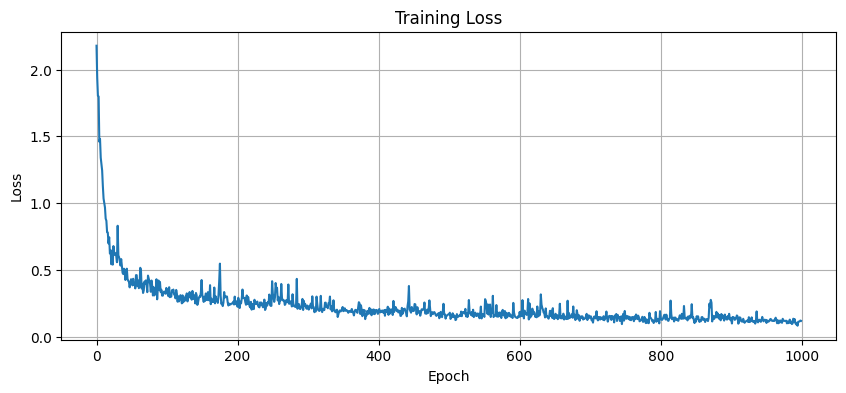

In [ ]:
# Plot training curve (robust)
loss_list = history.get("train_loss", None) if isinstance(history, dict) else None
if loss_list is None:
    loss_list = getattr(trainer, "history", {}).get("train_loss", [])

plt.figure(figsize=(10, 4))
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


## 3. static obstacle avoidance

In [2]:
import sys
from pathlib import Path

# 鎶婇」鐩牴鐩綍鍔犲叆 path
PROJECT_ROOT = Path().resolve().parents[1]   # 浠?notebooks/ 寰€涓婁袱绾n
sys.path.append(str(PROJECT_ROOT))

print("Added to path:", PROJECT_ROOT)


Added to path: D:\projects\lab2025


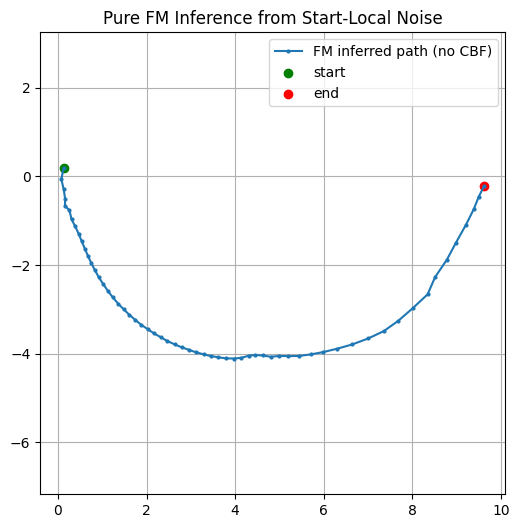

x_fm_norm: (5, 60) states: (60, 3) controls: (60, 2)


In [15]:
# Pure inference (no CBF) with start-neighborhood random noise
import numpy as np
import torch
import matplotlib.pyplot as plt
from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf, split_and_denormalize_5ch

# 1) Resolve model / device
model_5ch = trainer.model if "trainer" in globals() else model
model_5ch.eval()
device = next(model_5ch.parameters()).device

# 2) Pick one condition vector (if your model is conditional)
if "cond" in globals() and len(cond) > 0:
    cond_infer = cond[0]
else:
    cond_infer = None

# 3) Determine horizon and a start point in normalized XY
if "X1" in globals() and len(X1) > 0:
    T_steps = int(X1.shape[-1])
    start_xy_norm = np.asarray(X1[0, 0:2, 0], dtype=np.float32)
    goal_xy_norm = np.asarray(X1[0, 0:2, -1], dtype=np.float32)
else:
    T_steps = 60
    start_xy_norm = np.array([0.0, 0.0], dtype=np.float32)
    goal_xy_norm = None

# 4) Build initial noise around start neighborhood
noise_scale = 0.25
xy_sigma = 0.08
x0_noise = torch.randn((1, 5, T_steps), device=device) * noise_scale
x0_noise[:, 0, :] = float(start_xy_norm[0]) + xy_sigma * torch.randn((1, T_steps), device=device)
x0_noise[:, 1, :] = float(start_xy_norm[1]) + xy_sigma * torch.randn((1, T_steps), device=device)

# 5) FM sampling without CBF
x_fm_norm, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
    model_5ch=model_5ch,
    T_steps=T_steps,
    device=str(device),
    total_time=1.0,
    num_segments=20,
    ode_method="dopri5",
    atol=1e-5,
    rtol=1e-5,
    x0_noise=x0_noise,
    cond=cond_infer,
    start_xy_norm=start_xy_norm,
    start_guidance_weight=2.0,
    lock_start=False,
    goal_xy_norm=goal_xy_norm,
    goal_guidance_weight=1.0,
    goal_guidance_mode="endpoint",
    use_cbf=False,
)

# 6) Optional denormalization if scalers are available
if "state_scaler" in globals() and "control_scaler" in globals():
    states_denorm, controls_denorm = split_and_denormalize_5ch(
        x_fm_norm,
        state_scaler=state_scaler,
        control_scaler=control_scaler,
    )
else:
    states_denorm, controls_denorm = states_norm, controls_norm

# 7) Quick visualization
plt.figure(figsize=(6, 6))
plt.plot(states_denorm[:, 0], states_denorm[:, 1], "-o", markersize=2, label="FM inferred path (no CBF)")
plt.scatter(states_denorm[0, 0], states_denorm[0, 1], c="g", label="start")
plt.scatter(states_denorm[-1, 0], states_denorm[-1, 1], c="r", label="end")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Pure FM Inference from Start-Local Noise")
plt.show()

print("x_fm_norm:", x_fm_norm.shape, "states:", states_denorm.shape, "controls:", controls_denorm.shape)


In [12]:
import numpy as np
from pathlib import Path

# -------------------------
# 0) Where am I?
# -------------------------
CWD = Path().resolve()
print("[CWD]", CWD)

# -------------------------
# 1) Try to locate your dataset file automatically
# -------------------------
FNAME = "car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"

candidates = [
    CWD / "cache" / FNAME,              # notebooks/cache/...
    CWD.parent / "cache" / FNAME,       # repo_root/cache/... (if CWD=notebooks)
    Path("cache") / FNAME,              # relative cache/...
]

found = None
for p in candidates:
    if p.exists():
        found = p
        break

if found is None:
    raise FileNotFoundError(
        "Cannot find dataset file. Tried:\n" + "\n".join([str(p) for p in candidates])
    )

print("Found dataset:", found)

# -------------------------
# 2) Load dict
# -------------------------
data = np.load(str(found), allow_pickle=True).item()
print("keys:", list(data.keys()))

# -------------------------
# 3) Check required keys
# -------------------------
assert "states" in data, "Dataset missing key: 'states'"
assert "controls" in data, "Dataset missing key: 'controls'"

states = np.asarray(data["states"], dtype=np.float32)
controls = np.asarray(data["controls"], dtype=np.float32)

print("states shape:", states.shape)
print("controls shape:", controls.shape)

# -------------------------
# 4) Shape sanity checks (match your 5-ch training / sampler)
# -------------------------
assert states.ndim == 3 and states.shape[2] >= 3, "states must be (N,T,D>=3)"
assert controls.ndim == 3 and controls.shape[2] == 2, "controls must be (N,T,2)"
assert states.shape[0] == controls.shape[0], "N mismatch between states and controls"
assert states.shape[1] == controls.shape[1], "T mismatch between states and controls"

N, T, D = states.shape
print(f"N={N}, T={T}, D={D} (you will use first 3 for state)")

# -------------------------
# 5) NaN/Inf checks
# -------------------------
def _chk(name, arr):
    bad = ~np.isfinite(arr)
    if bad.any():
        idx = np.argwhere(bad)[0]
        raise ValueError(f"{name} has NaN/Inf at index {tuple(idx)} value={arr[tuple(idx)]}")
_chk("states", states)
_chk("controls", controls)
print("No NaN/Inf")

# -------------------------
# 6) Build scalers consistent with your 5ch definition
#    [x,y,theta,a,delta_rate]
# -------------------------
flat5 = np.concatenate([states[:, :, :3], controls[:, :, :2]], axis=2).reshape(-1, 5)
dmin = flat5.min(axis=0)
dmax = flat5.max(axis=0)

class Scaler:
    def __init__(self, mn, mx):
        self.min = np.asarray(mn, dtype=np.float32)
        self.max = np.asarray(mx, dtype=np.float32)
    def normalize(self, x):
        x = np.asarray(x, dtype=np.float32)
        return 2.0 * (x - self.min) / (self.max - self.min + 1e-12) - 1.0
    def denormalize(self, x):
        x = np.asarray(x, dtype=np.float32)
        return (x + 1.0) * 0.5 * (self.max - self.min) + self.min

state_scaler   = Scaler(dmin[:3], dmax[:3])
control_scaler = Scaler(dmin[3:], dmax[3:])

print("state_scaler min/max:", state_scaler.min, state_scaler.max)
print("ctrl  scaler min/max:", control_scaler.min, control_scaler.max)

# If you want: build your training tensor (N,5,T) quickly:
traj_5ch = np.concatenate([states[:, :, :3], controls], axis=2).transpose(0, 2, 1)  # (N,5,T)
print("traj_5ch (N,5,T):", traj_5ch.shape)


[CWD] D:\projects\lab2025\dmpc_fm_cbf\notebooks
Found dataset: D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy
keys: ['traj_xy', 'states', 'controls', 'refs_xy', 'goals', 'theta0', 'params', 'vel_xy', 'vel_xy_N2T', 'vel_xy_Tm1', 'vel_xy_Tm1_N2T', 'omega']
states shape: (100, 60, 5)
controls shape: (100, 60, 2)
N=100, T=60, D=5 (you will use first 3 for state)
No NaN/Inf
state_scaler min/max: [-2.9525704 -2.9281785 -3.1415234] [2.9558294 2.9845314 3.138993 ]
ctrl  scaler min/max: [-0.8       -2.0943952] [0.8       2.0943952]
traj_5ch (N,5,T): (100, 5, 60)


In [4]:
import importlib.util
from pathlib import Path

def find_src_dir(start: Path) -> Path:
    """
    Walk upward from start to find the repo layout:
      <ROOT>/dmpc_fm_cbf/dmpc_fm_cbf/cbf_project_velocity_sgfm.py
    Return: <ROOT>/dmpc_fm_cbf/dmpc_fm_cbf
    """
    start = start.resolve()
    for p in [start] + list(start.parents):
        candidate = p / "dmpc_fm_cbf" / "dmpc_fm_cbf" / "cbf_project_velocity_sgfm.py"
        if candidate.exists():
            return p / "dmpc_fm_cbf" / "dmpc_fm_cbf"
    raise FileNotFoundError(
        "Cannot locate source dir. Tried upward from:\n"
        f"  {start}\n"
        "Expected to find:\n"
        "  dmpc_fm_cbf/dmpc_fm_cbf/cbf_project_velocity_sgfm.py"
    )

# 1) locate SRC_DIR robustly
CWD = Path.cwd()
SRC_DIR = find_src_dir(CWD)
print("[CWD    ]", CWD)
print("[SRC_DIR]", SRC_DIR)

# 2) load CBF module by absolute path
cbf_path = SRC_DIR / "cbf_project_velocity_sgfm.py"
spec_cbf = importlib.util.spec_from_file_location("cbf_project_velocity_sgfm", cbf_path)
cbfmod = importlib.util.module_from_spec(spec_cbf)
spec_cbf.loader.exec_module(cbfmod)

print("[USING CBF]", cbfmod.__file__)
print("[CBF FN ]", cbfmod.cbf_project_velocity_sgfm)

# 3) load sampler module by absolute path
sampler_path = SRC_DIR / "sampler_5h.py"
spec_sampler = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_5h = importlib.util.module_from_spec(spec_sampler)
spec_sampler.loader.exec_module(sampler_5h)

print("[USING SAMPLER]", sampler_5h.__file__)

# 4) function handles
piecewise_sample_fm_5ch_with_cbf = sampler_5h.piecewise_sample_fm_5ch_with_cbf
split_and_denormalize_5ch        = sampler_5h.split_and_denormalize_5ch

print("✅ Robust absolute-path import works.")


[CWD    ] d:\projects\lab2025\dmpc_fm_cbf\notebooks
[SRC_DIR] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf
[USING CBF] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[CBF FN ] <function cbf_project_velocity_sgfm at 0x00000246656F93A0>
[USING SAMPLER] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
✅ Robust absolute-path import works.


[CWD] d:\projects\lab2025\dmpc_fm_cbf\notebooks
[REPO_ROOT] d:\projects\lab2025\dmpc_fm_cbf
[SRC_DIR] d:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\dmpc_fm_cbf
[CACHE_DIR] d:\projects\lab2025\dmpc_fm_cbf\notebooks\cache
[device] cuda
[Loaded ckpt] d:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\model_vel_5ch_canonical_r.pt
[T_steps] 60
min_clear no-cbf : -0.104707270860672
min_clear with-cbf: 0.043196022510528564


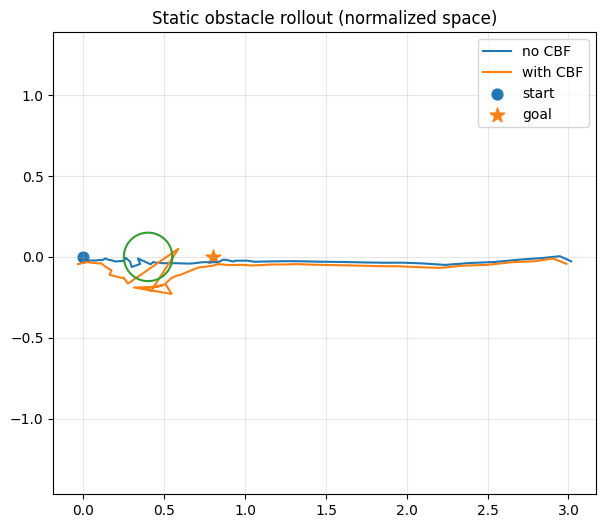

In [6]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# 0) locate paths
# -----------------------
CWD = Path.cwd()
REPO_ROOT = CWD.parent
SRC_DIR = REPO_ROOT / "dmpc_fm_cbf" / "dmpc_fm_cbf"
CACHE_DIR = REPO_ROOT / "notebooks" / "cache"

print("[CWD]", CWD)
print("[REPO_ROOT]", REPO_ROOT)
print("[SRC_DIR]", SRC_DIR)
print("[CACHE_DIR]", CACHE_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# -----------------------
# 1) load modules (assume you already ran the loader cell)
# -----------------------
# piecewise_sample_fm_5ch_with_cbf, split_and_denormalize_5ch are already available

# -----------------------
# 2) load model checkpoint
# -----------------------
CKPT_PATH = CACHE_DIR / "model_vel_5ch_canonical_r.pt"
assert CKPT_PATH.exists(), f"Missing ckpt: {CKPT_PATH}"

from fmtorch.models.simple1d_unet import SimpleUNet1D

model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

ckpt = torch.load(str(CKPT_PATH), map_location=device)
if "model_state_dict" in ckpt:
    model_5ch.load_state_dict(ckpt["model_state_dict"], strict=True)
else:
    model_5ch.load_state_dict(ckpt, strict=True)

model_5ch.eval()
print("[Loaded ckpt]", CKPT_PATH)

# -----------------------
# 3) load dataset to get T_steps (and for scalers if you want)
# -----------------------
DATA_PATH = CACHE_DIR / "car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"

data = np.load(str(DATA_PATH), allow_pickle=True).item()
states_np = np.asarray(data["states"], dtype=np.float32)   # (N,T,5)
controls_np= np.asarray(data["controls"], dtype=np.float32) # (N,T,2)

T_steps = int(states_np.shape[1])
print("[T_steps]", T_steps)

# -----------------------
# 4) define canonical start/goal & obstacle in SAME SPACE as x_norm XY
#     (你当前 sampler 假设 ellipses 的 center/radius 和 x_norm[:,0:2,:] 是同一空间)
# -----------------------
# 如果你现在 x_norm 是 canonical-normalized [-1,1] 空间，那 center 也要用这个空间！
start_xy_norm = np.array([0.0, 0.0], np.float32)
goal_xy_norm  = np.array([0.8, 0.0], np.float32)   # 举例：往 x 正方向

ellipses = [
    {"center": np.array([0.4, 0.0], np.float32), "radius": 0.15},
]

# -----------------------
# 5) init noise
# -----------------------
torch.manual_seed(0)
x0_noise = torch.randn((1,5,T_steps), device=device)

# -----------------------
# 6) run A/B
# -----------------------
common = dict(
    model_5ch=model_5ch,
    T_steps=T_steps,
    device=str(device),
    total_time=1.0,
    num_segments=20,
    ode_method="dopri5",
    atol=1e-5,
    rtol=1e-5,
    x0_noise=x0_noise,
    cond=np.array([1.0, 0.0, 1.0, 0.0, 0.0], np.float32),  # 先给个dummy cond，后面你替换成真实 cond_vec
    start_xy_norm=start_xy_norm,
    goal_xy_norm=goal_xy_norm,
    goal_guidance_weight=0.25,
    goal_guidance_mode="tail",
    ellipses=ellipses,
    cbf_kwargs=dict(
        MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=1.0,
        passes=20, extra_margin=0.05, max_corr_norm=2.0, alpha=8.0
    ),
)

x_no, _, _   = piecewise_sample_fm_5ch_with_cbf(use_cbf=False, **common)
x_yes, _, _  = piecewise_sample_fm_5ch_with_cbf(use_cbf=True,  **common)

xy_no  = x_no[0:2,:].T
xy_yes = x_yes[0:2,:].T

# -----------------------
# 7) simple metrics + plot
# -----------------------
def min_clear(xy, ellipses):
    xy = np.asarray(xy)
    m = 1e9
    for e in ellipses:
        c = np.asarray(e["center"]).reshape(1,2)
        r = float(e["radius"])
        d = np.linalg.norm(xy - c, axis=1) - r
        m = min(m, float(d.min()))
    return m

print("min_clear no-cbf :", min_clear(xy_no, ellipses))
print("min_clear with-cbf:", min_clear(xy_yes, ellipses))

plt.figure(figsize=(7,6))
plt.plot(xy_no[:,0],  xy_no[:,1],  label="no CBF")
plt.plot(xy_yes[:,0], xy_yes[:,1], label="with CBF")
plt.scatter([start_xy_norm[0]],[start_xy_norm[1]], s=60, label="start")
plt.scatter([goal_xy_norm[0]],[goal_xy_norm[1]], s=120, marker="*", label="goal")
for e in ellipses:
    c = e["center"]; r = e["radius"]
    th = np.linspace(0,2*np.pi,256)
    plt.plot(c[0]+r*np.cos(th), c[1]+r*np.sin(th))
plt.axis("equal"); plt.grid(True, alpha=0.3); plt.legend(); plt.title("Static obstacle rollout (normalized space)")
plt.show()


In [8]:
# ===============================================================
# ✅ Robust package import (NO absolute-path spec) + safe reload
# Works for your structure:
#   dmpc_fm_cbf/
#     notebooks/ demo.ipynb   (CWD here)
#     dmpc_fm_cbf/  (actual python package)
# ===============================================================

import sys, importlib
from pathlib import Path

# 1) locate repo root (outer folder that contains inner package folder)
CWD = Path().resolve()  # .../dmpc_fm_cbf/notebooks
REPO_ROOT = CWD.parent  # .../dmpc_fm_cbf
assert (REPO_ROOT / "dmpc_fm_cbf").exists(), f"Inner package folder not found: {REPO_ROOT/'dmpc_fm_cbf'}"
assert (REPO_ROOT / "dmpc_fm_cbf" / "__init__.py").exists(), "Missing __init__.py in inner package!"

# 2) ensure ONLY the correct root is on sys.path (avoid double-layer confusion)
repo_root_str = str(REPO_ROOT)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

print("[CWD      ]", CWD)
print("[REPO_ROOT]", REPO_ROOT)
print("[sys.path0]", sys.path[0])

# 3) clear possibly-stale modules from previous failed imports/spec-loads
#    (this prevents: "module xxx not in sys.modules" + wrong __file__)
to_purge = [
    "cbf_project_velocity_sgfm",  # sometimes left by spec-load attempts
    "sampler_5h",
    "dmpc_fm_cbf.cbf_project_velocity_sgfm",
    "dmpc_fm_cbf.sampler_5h",
]
for k in to_purge:
    if k in sys.modules:
        del sys.modules[k]

# 4) import via package path + reload
import dmpc_fm_cbf.cbf_project_velocity_sgfm as cbfmod
import dmpc_fm_cbf.sampler_5h as sampler_5h
cbfmod = importlib.reload(cbfmod)
sampler_5h = importlib.reload(sampler_5h)

print("[USING CBF   ]", cbfmod.__file__)
print("[USING sampler]", sampler_5h.__file__)
print("[CBF fn      ]", cbfmod.cbf_project_velocity_sgfm)

# 5) convenient handles
piecewise_sample_fm_5ch_with_cbf = sampler_5h.piecewise_sample_fm_5ch_with_cbf
split_and_denormalize_5ch        = sampler_5h.split_and_denormalize_5ch

print("✅ Package import + reload OK")


[CWD      ] D:\projects\lab2025\dmpc_fm_cbf\notebooks
[REPO_ROOT] D:\projects\lab2025\dmpc_fm_cbf
[sys.path0] d:\projects\lab2025\dmpc_fm_cbf
[USING CBF   ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[CBF fn      ] <function cbf_project_velocity_sgfm at 0x000002466D796340>
✅ Package import + reload OK


min_clear no-cbf : -0.2481566071510315
min_clear with-cbf: 0.00517648458480835
smooth   no-cbf : 0.01730736903846264
smooth   with-cbf: 0.01788918860256672
goal_err no-cbf : 2.233290910720825
goal_err with-cbf: 2.2045891284942627


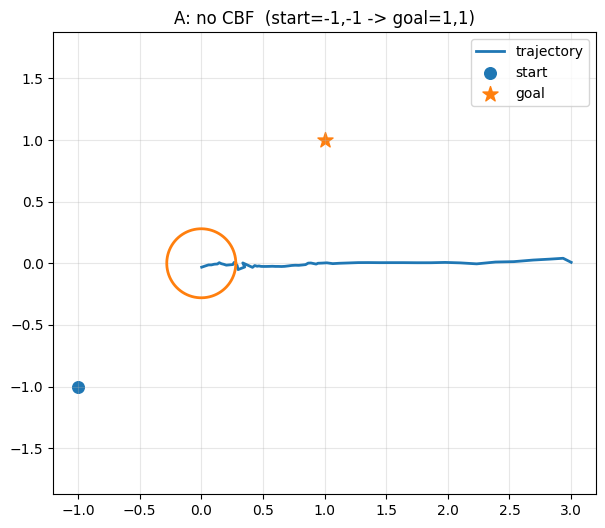

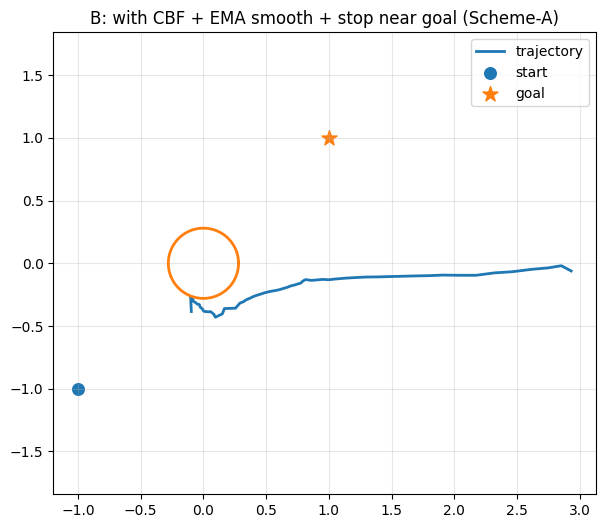

In [10]:
# ===============================================================
# Static obstacle rollout (5ch FM sampler) + Scheme-A (EMA smoothing)
# 1) start (-1,-1), goal (1,1)
# 2) stronger CBF
# 3) stop near goal (damping v_xy near goal)
# Two figures: no CBF vs with CBF
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# 7) Start/Goal in "plot world" (use [-1,1] box)
# -----------------------
x0_xy   = np.array([-1.0, -1.0], np.float32)
goal_xy = np.array([ 1.0,  1.0], np.float32)

# In your current demo, xy we plot is directly x_no[0:2].T (normalized space)
# So we set start_xy_norm/goal_xy_norm to the same values.
start_xy_norm = x0_xy.copy()
goal_xy_norm  = goal_xy.copy()

# -----------------------
# 8) Obstacle: place it on the straight line between start->goal
# -----------------------
mid = 0.5 * (x0_xy + goal_xy)
ellipses = [
    {"center": mid.astype(np.float32), "radius": 0.28},   # stronger obstacle
]

# -----------------------
# 9) Init noise + force frame-0 token to match start (Scheme-A boundary)
#    - keep noise for all frames
#    - overwrite frame-0 with correct start token (xy=start, others 0)
# -----------------------
torch.manual_seed(0)
x0_noise = torch.randn((1, 5, T_steps), device=device)

# We only know XY start here; keep theta/a/r_dot = 0 in normalized demo
x0_noise[:, :, 0] = 0.0
x0_noise[:, 0, 0] = float(start_xy_norm[0])
x0_noise[:, 1, 0] = float(start_xy_norm[1])

# -----------------------
# 10) Goal-stop damping (mentor-style: inside RHS before returning v)
#     We'll implement by wrapping model_5ch output:
#       - compute v_pred = model(x,t,cond)
#       - apply goal guidance
#       - apply CBF on v_xy
#       - finally apply stop gate: v_xy *= stop_gate(xy, goal)
# -----------------------
class StopNearGoalWrapper(nn.Module):
    def __init__(self, base_model, goal_xy_norm, stop_radius=0.12, stop_power=2.0):
        super().__init__()
        self.base = base_model
        self.goal = torch.tensor(goal_xy_norm, dtype=torch.float32)
        self.stop_radius = float(stop_radius)
        self.stop_power  = float(stop_power)

    def forward(self, x, t, cond=None):
        # base v
        v = self.base(x, t, cond)

        # compute stop gate per time index based on distance to goal
        # x: (1,5,T) -> xy: (1,2,T)
        xy = x[:, 0:2, :]
        g  = self.goal.to(device=xy.device, dtype=xy.dtype).view(1,2,1)
        dist = torch.linalg.norm(xy - g, dim=1, keepdim=True)  # (1,1,T)

        # stop_gate: far -> 1, near -> 0
        # smooth: (dist/stop_radius) clipped to [0,1], then power
        z = (dist / max(1e-6, self.stop_radius)).clamp(0.0, 1.0)
        stop_gate = (z ** self.stop_power)  # near 0 -> 0, far -> 1

        # damp XY velocity only
        v[:, 0:2, :] = v[:, 0:2, :] * stop_gate
        return v

# Wrap the trained model so it naturally "stops near goal"
model_5ch_stop = StopNearGoalWrapper(model_5ch, goal_xy_norm, stop_radius=0.18, stop_power=2.0).to(device)
model_5ch_stop.eval()

# -----------------------
# 11) Run A/B sampling (stronger CBF)
# -----------------------
common = dict(
    model_5ch=model_5ch_stop,
    T_steps=T_steps,
    device=str(device),

    total_time=1.0,
    num_segments=25,          # a bit finer integration -> smoother
    ode_method="dopri5",
    atol=1e-5,
    rtol=1e-5,

    x0_noise=x0_noise,

    # keep your cond shape
    cond=np.array([1.0, 0.0, 1.0, 0.0, 0.0], np.float32),

    start_xy_norm=start_xy_norm,
    goal_xy_norm=goal_xy_norm,
    goal_guidance_weight=0.35,     # stronger goal pull
    goal_guidance_mode="tail",

    ellipses=ellipses,

    # mentor-structure gate params inside sampler (MASK_GATE * time_gate_ft)
    cbf_kwargs=dict(
        MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=1.0,

        # 🔥 stronger CBF
        passes=25,
        alpha=14.0,
        max_corr_norm=4.0,
        extra_margin=0.12,

        # Scheme-A smooth
        ema_beta=0.93,
    ),
)

x_no, _, _  = piecewise_sample_fm_5ch_with_cbf(use_cbf=False, **common)
x_yes, _, _ = piecewise_sample_fm_5ch_with_cbf(use_cbf=True,  **common)

xy_no  = x_no[0:2, :].T
xy_yes = x_yes[0:2, :].T

# -----------------------
# 12) Metrics helpers
# -----------------------
def min_clear(xy, ellipses):
    xy = np.asarray(xy, dtype=np.float32)
    m = 1e9
    for e in ellipses:
        c = np.asarray(e["center"], dtype=np.float32).reshape(1,2)
        r = float(e["radius"])
        d = np.linalg.norm(xy - c, axis=1) - r
        m = min(m, float(d.min()))
    return m

def smoothness_metric(xy):
    xy = np.asarray(xy, dtype=np.float32)
    d1 = np.diff(xy, axis=0)
    d2 = np.diff(d1, axis=0)
    return float(np.mean(np.linalg.norm(d2, axis=1)))

def goal_err(xy, g):
    return float(np.linalg.norm(np.asarray(xy, np.float32)[-1] - np.asarray(g, np.float32)))

print("min_clear no-cbf :", min_clear(xy_no, ellipses))
print("min_clear with-cbf:", min_clear(xy_yes, ellipses))
print("smooth   no-cbf :", smoothness_metric(xy_no))
print("smooth   with-cbf:", smoothness_metric(xy_yes))
print("goal_err no-cbf :", goal_err(xy_no, goal_xy))
print("goal_err with-cbf:", goal_err(xy_yes, goal_xy))

# -----------------------
# 13) Plot TWO figures
# -----------------------
def plot_one(xy, title):
    plt.figure(figsize=(7,6))
    plt.plot(xy[:,0], xy[:,1], linewidth=2, label="trajectory")
    plt.scatter([x0_xy[0]],[x0_xy[1]], s=70, label="start")
    plt.scatter([goal_xy[0]],[goal_xy[1]], s=130, marker="*", label="goal")

    for e in ellipses:
        c = np.asarray(e["center"], dtype=np.float32)
        r = float(e["radius"])
        th = np.linspace(0, 2*np.pi, 256)
        plt.plot(c[0] + r*np.cos(th), c[1] + r*np.sin(th), linewidth=2)

    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()

plot_one(xy_no,  "A: no CBF  (start=-1,-1 -> goal=1,1)")
plot_one(xy_yes, "B: with CBF + EMA smooth + stop near goal (Scheme-A)")


[canonical] start [0. 0.]  goal [2.828427 0.      ]  dist 2.8284270763397217
[canonical] obstacles [{'center': array([1.4142135, 0.       ], dtype=float32), 'radius': 0.25}]


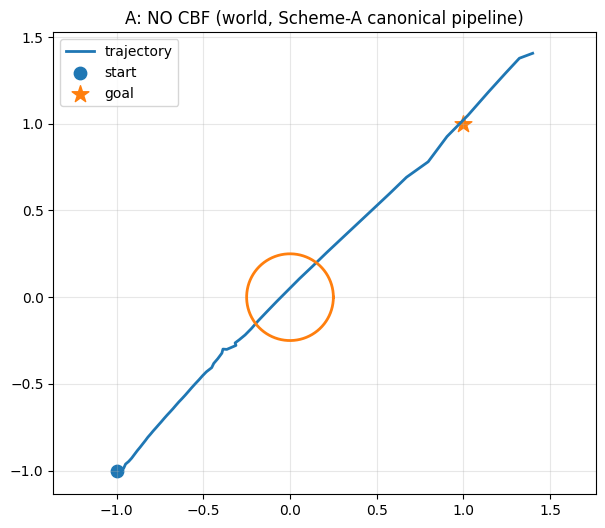

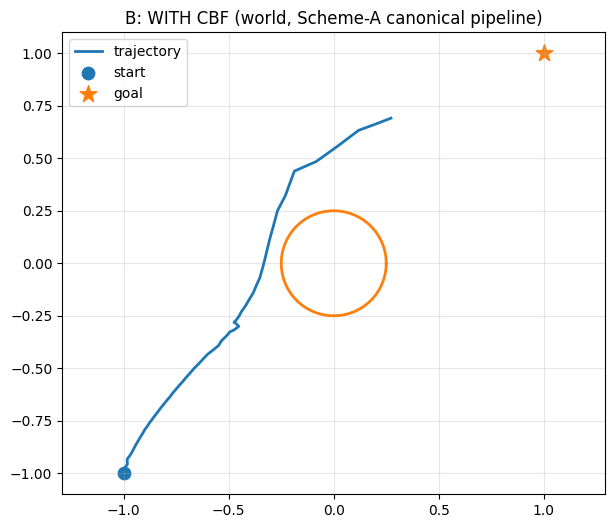

In [12]:
# ===============================================================
# Scheme-A (RECOMMENDED): Strict canonical -> FM/CBF in canonical -> back to world
# - Start fixed: world (-1,-1), goal (1,1)
# - CBF stronger
# - Stop near goal (damping) in canonical
# - Two figures: no CBF vs with CBF
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# 0) user setup: world start/goal, world obstacles
# -----------------------
x0_world   = np.array([-1.0, -1.0], np.float32)
goal_world = np.array([ 1.0,  1.0], np.float32)

# world obstacle circles (example; replace with yours)
# NOTE: keep in WORLD here; we will canonicalize them.
ellipses_world = [
    {"center": np.array([0.0, 0.0], np.float32), "radius": 0.25},
]

# stop-near-goal radius in CANONICAL
STOP_R = 0.15
STOP_K = 2.5  # damping strength

# -----------------------
# 1) build SE(2) canonical transform from x0_world and goal_world
#    canonical:
#      x0 -> (0,0)
#      goal -> (d,0)
# -----------------------
gvec = (goal_world - x0_world).astype(np.float32)
dist = float(np.linalg.norm(gvec) + 1e-9)

ex = (gvec / dist).reshape(2,1)                  # canonical x-axis in world coords
ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)  # 90deg rot

R_cw = np.concatenate([ex, ey], axis=1)  # (2,2): canonical -> world
R_wc = R_cw.T                            # world -> canonical

def world_to_can_xy(xy_world: np.ndarray) -> np.ndarray:
    xy_world = np.asarray(xy_world, np.float32).reshape(-1,2)
    return ((R_wc @ (xy_world - x0_world).T).T).astype(np.float32)

def can_to_world_xy(xy_can: np.ndarray) -> np.ndarray:
    xy_can = np.asarray(xy_can, np.float32).reshape(-1,2)
    return ((R_cw @ xy_can.T).T + x0_world).astype(np.float32)

# canonical start/goal
start_can = np.array([0.0, 0.0], np.float32)
goal_can  = np.array([dist, 0.0], np.float32)

# canonical obstacles
ellipses_can = []
for e in ellipses_world:
    c_can = world_to_can_xy(e["center"].reshape(1,2))[0]
    ellipses_can.append({"center": c_can.astype(np.float32), "radius": float(e["radius"])})

print("[canonical] start", start_can, " goal", goal_can, " dist", dist)
print("[canonical] obstacles", ellipses_can)

# -----------------------
# 2) Make x0_noise in CANONICAL space
#    IMPORTANT: the whole XY token sequence should start near (0,0)
# -----------------------
torch.manual_seed(0)
x0_noise = torch.randn((1, 5, T_steps), device=device)

# init XY tokens near canonical start
x0_noise[:,0,:] = 0.02 * torch.randn((1,T_steps), device=device)
x0_noise[:,1,:] = 0.02 * torch.randn((1,T_steps), device=device)
x0_noise[:,0,0] = 0.0
x0_noise[:,1,0] = 0.0

# keep other channels small for stability (optional)
x0_noise[:,2:,:] = 0.0

# -----------------------
# 3) STOP-near-goal wrapper by patching the model output inside RHS (mentor style)
#    We do it by wrapping model_5ch forward: v <- v - k * (x - goal) when close
# -----------------------
class StopNearGoalWrapper(torch.nn.Module):
    def __init__(self, base_model, goal_can_xy, r=0.15, k=2.5):
        super().__init__()
        self.base = base_model
        self.goal = torch.tensor(goal_can_xy, dtype=torch.float32, device=device).view(1,2,1)  # (1,2,1)
        self.r = float(r)
        self.k = float(k)

    def forward(self, x, t, cond=None):
        v = self.base(x, t, cond=cond)  # (1,5,T)
        xy = x[:,0:2,:]
        d  = xy - self.goal
        dist2 = (d*d).sum(dim=1, keepdim=True)  # (1,1,T)
        mask = (dist2 <= (self.r*self.r)).float()
        # damping: subtract radial component toward motion (simple proportional)
        v_xy = v[:,0:2,:] - mask * (self.k * d)
        v = v.clone()
        v[:,0:2,:] = v_xy
        return v

model_5ch_stop = StopNearGoalWrapper(model_5ch, goal_can, r=STOP_R, k=STOP_K).to(device).eval()

# -----------------------
# 4) Common sampling args (CANONICAL everywhere!)
# -----------------------
common = dict(
    model_5ch=model_5ch_stop,         # wrapped model (stop near goal)
    T_steps=T_steps,
    device=str(device),
    total_time=1.0,
    num_segments=25,
    ode_method="dopri5",
    atol=1e-5,
    rtol=1e-5,
    x0_noise=x0_noise,
    cond=np.array([1,0,1,0,0], np.float32),  # your cond; replace if you have real one
    start_xy_norm=start_can,           # CANONICAL start
    goal_xy_norm=goal_can,             # CANONICAL goal
    goal_guidance_weight=0.35,
    goal_guidance_mode="tail",
    ellipses=ellipses_can,             # CANONICAL obstacles
    cbf_kwargs=dict(
        # time gate: enable early
        MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.1,
        # stronger cbf
        passes=20,
        extra_margin=0.25,
        max_corr_norm=4.0,
        alpha=20.0,
        # Scheme-A EMA smoothing if you patched projector externally:
        # ema_beta=0.92,
    ),
)

# -----------------------
# 5) Run no-cbf / with-cbf in canonical
# -----------------------
x_no_can,  _, _ = piecewise_sample_fm_5ch_with_cbf(use_cbf=False, **common)
x_yes_can, _, _ = piecewise_sample_fm_5ch_with_cbf(use_cbf=True,  **common)

xy_no_can  = x_no_can[0:2,:].T
xy_yes_can = x_yes_can[0:2,:].T

# map to world
xy_no_world  = can_to_world_xy(xy_no_can)
xy_yes_world = can_to_world_xy(xy_yes_can)

# -----------------------
# 6) plots (TWO figures, world)
# -----------------------
def plot_world(xy_world, title, obstacles_world):
    plt.figure(figsize=(7,6))
    plt.plot(xy_world[:,0], xy_world[:,1], linewidth=2, label="trajectory")
    plt.scatter([x0_world[0]],[x0_world[1]], s=80, label="start")
    plt.scatter([goal_world[0]],[goal_world[1]], s=160, marker="*", label="goal")
    for e in obstacles_world:
        c = np.asarray(e["center"], np.float32).reshape(2)
        r = float(e["radius"])
        th = np.linspace(0, 2*np.pi, 256)
        plt.plot(c[0]+r*np.cos(th), c[1]+r*np.sin(th), linewidth=2)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()

plot_world(xy_no_world,  "A: NO CBF (world, Scheme-A canonical pipeline)", ellipses_world)
plot_world(xy_yes_world, "B: WITH CBF (world, Scheme-A canonical pipeline)", ellipses_world)


[canonical] start [0. 0.]  goal [2.828427 0.      ]  dist 2.8284270763397217
[canonical] obstacles [{'center': array([1.767767 , 0.0707106], dtype=float32), 'radius': 0.25}]


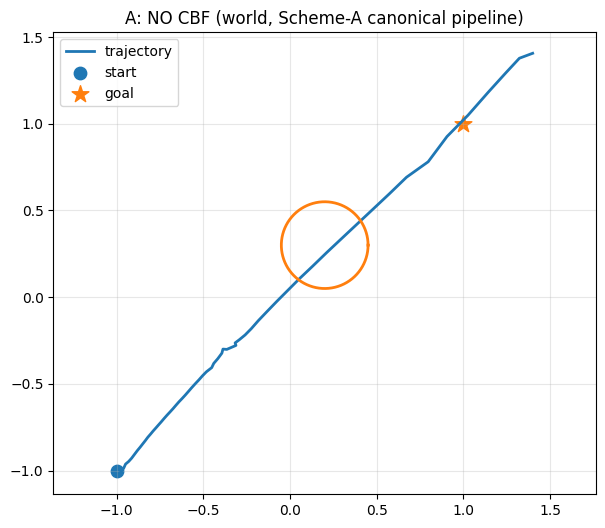

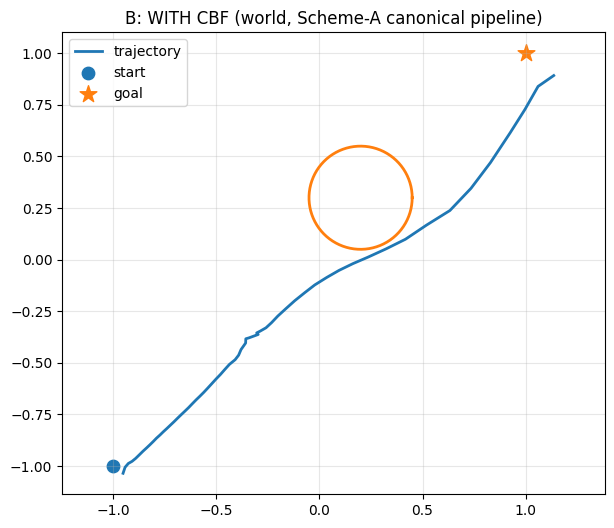

In [15]:
# ===============================================================
# Scheme-A (RECOMMENDED): Strict canonical -> FM/CBF in canonical -> back to world
# - Start fixed: world (-1,-1), goal (1,1)
# - CBF stronger
# - Stop near goal (damping) in canonical
# - Two figures: no CBF vs with CBF
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# 0) user setup: world start/goal, world obstacles
# -----------------------
x0_world   = np.array([-1.0, -1.0], np.float32)
goal_world = np.array([ 1.0,  1.0], np.float32)

# world obstacle circles (example; replace with yours)
# NOTE: keep in WORLD here; we will canonicalize them.
ellipses_world = [
    {"center": np.array([0.2, 0.3], np.float32), "radius": 0.25},
]

# stop-near-goal radius in CANONICAL
STOP_R = 0.15
STOP_K = 2.5  # damping strength

# -----------------------
# 1) build SE(2) canonical transform from x0_world and goal_world
#    canonical:
#      x0 -> (0,0)
#      goal -> (d,0)
# -----------------------
gvec = (goal_world - x0_world).astype(np.float32)
dist = float(np.linalg.norm(gvec) + 1e-9)

ex = (gvec / dist).reshape(2,1)                  # canonical x-axis in world coords
ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)  # 90deg rot

R_cw = np.concatenate([ex, ey], axis=1)  # (2,2): canonical -> world
R_wc = R_cw.T                            # world -> canonical

def world_to_can_xy(xy_world: np.ndarray) -> np.ndarray:
    xy_world = np.asarray(xy_world, np.float32).reshape(-1,2)
    return ((R_wc @ (xy_world - x0_world).T).T).astype(np.float32)

def can_to_world_xy(xy_can: np.ndarray) -> np.ndarray:
    xy_can = np.asarray(xy_can, np.float32).reshape(-1,2)
    return ((R_cw @ xy_can.T).T + x0_world).astype(np.float32)

# canonical start/goal
start_can = np.array([0.0, 0.0], np.float32)
goal_can  = np.array([dist, 0.0], np.float32)

# canonical obstacles
ellipses_can = []
for e in ellipses_world:
    c_can = world_to_can_xy(e["center"].reshape(1,2))[0]
    ellipses_can.append({"center": c_can.astype(np.float32), "radius": float(e["radius"])})

print("[canonical] start", start_can, " goal", goal_can, " dist", dist)
print("[canonical] obstacles", ellipses_can)

# -----------------------
# 2) Make x0_noise in CANONICAL space
#    IMPORTANT: the whole XY token sequence should start near (0,0)
# -----------------------
torch.manual_seed(0)
x0_noise = torch.randn((1, 5, T_steps), device=device)

# init XY tokens near canonical start
x0_noise[:,0,:] = 0.02 * torch.randn((1,T_steps), device=device)
x0_noise[:,1,:] = 0.02 * torch.randn((1,T_steps), device=device)
x0_noise[:,0,0] = 0.0
x0_noise[:,1,0] = 0.0

# keep other channels small for stability (optional)
x0_noise[:,2:,:] = 0.0

# -----------------------
# 3) STOP-near-goal wrapper by patching the model output inside RHS (mentor style)
#    We do it by wrapping model_5ch forward: v <- v - k * (x - goal) when close
# -----------------------
class StopNearGoalWrapper(torch.nn.Module):
    def __init__(self, base_model, goal_can_xy, r=0.15, k=2.5):
        super().__init__()
        self.base = base_model
        self.goal = torch.tensor(goal_can_xy, dtype=torch.float32, device=device).view(1,2,1)  # (1,2,1)
        self.r = float(r)
        self.k = float(k)

    def forward(self, x, t, cond=None):
        v = self.base(x, t, cond=cond)  # (1,5,T)
        xy = x[:,0:2,:]
        d  = xy - self.goal
        dist2 = (d*d).sum(dim=1, keepdim=True)  # (1,1,T)
        mask = (dist2 <= (self.r*self.r)).float()
        # damping: subtract radial component toward motion (simple proportional)
        v_xy = v[:,0:2,:] - mask * (self.k * d)
        v = v.clone()
        v[:,0:2,:] = v_xy
        return v

model_5ch_stop = StopNearGoalWrapper(model_5ch, goal_can, r=STOP_R, k=STOP_K).to(device).eval()

# -----------------------
# 4) Common sampling args (CANONICAL everywhere!)
# -----------------------
common = dict(
    model_5ch=model_5ch_stop,         # wrapped model (stop near goal)
    T_steps=T_steps,
    device=str(device),
    total_time=1.0,
    num_segments=25,
    ode_method="dopri5",
    atol=1e-5,
    rtol=1e-5,
    x0_noise=x0_noise,
    cond=np.array([1,0,1,0,0], np.float32),  # your cond; replace if you have real one
    start_xy_norm=start_can,           # CANONICAL start
    goal_xy_norm=goal_can,             # CANONICAL goal
    goal_guidance_weight=0.35,
    goal_guidance_mode="tail",
    ellipses=ellipses_can,             # CANONICAL obstacles
    cbf_kwargs=dict(
        # time gate: enable early
        MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.1,
        # stronger cbf
        passes=20,
        extra_margin=0.25,
        max_corr_norm=4.0,
        alpha=20.0,
        # Scheme-A EMA smoothing if you patched projector externally:
        # ema_beta=0.92,
    ),
)

# -----------------------
# 5) Run no-cbf / with-cbf in canonical
# -----------------------
x_no_can,  _, _ = piecewise_sample_fm_5ch_with_cbf(use_cbf=False, **common)
x_yes_can, _, _ = piecewise_sample_fm_5ch_with_cbf(use_cbf=True,  **common)

xy_no_can  = x_no_can[0:2,:].T
xy_yes_can = x_yes_can[0:2,:].T

# map to world
xy_no_world  = can_to_world_xy(xy_no_can)
xy_yes_world = can_to_world_xy(xy_yes_can)

# -----------------------
# 6) plots (TWO figures, world)
# -----------------------
def plot_world(xy_world, title, obstacles_world):
    plt.figure(figsize=(7,6))
    plt.plot(xy_world[:,0], xy_world[:,1], linewidth=2, label="trajectory")
    plt.scatter([x0_world[0]],[x0_world[1]], s=80, label="start")
    plt.scatter([goal_world[0]],[goal_world[1]], s=160, marker="*", label="goal")
    for e in obstacles_world:
        c = np.asarray(e["center"], np.float32).reshape(2)
        r = float(e["radius"])
        th = np.linspace(0, 2*np.pi, 256)
        plt.plot(c[0]+r*np.cos(th), c[1]+r*np.sin(th), linewidth=2)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()

plot_world(xy_no_world,  "A: NO CBF (world, Scheme-A canonical pipeline)", ellipses_world)
plot_world(xy_yes_world, "B: WITH CBF (world, Scheme-A canonical pipeline)", ellipses_world)
